In [3]:
import numpy as np
import functools

# This includes a few heuristics that solved a few "hard" puzzles. It should include
# a final brute-force step to guarantee that it finds a solution to all solvable
# puzzles.

class Sudoku:
    def __init__(self, puzzle):
        self.expanded = list(map(lambda row: 
            list(map(lambda col: set(range(1,10)) if col==0 else set([col]), row)), puzzle
        ))
    
    # Convert puzzle into ASCII art image
    def __repr__(self):
        ret = ''
        
        # maps a set to a 3x3 array padded with zeros
        fun = lambda x: np.reshape(np.pad(np.array(list(x)), (0,9-len(x))),(3,3))
        mat = np.vstack([np.hstack(list(map(lambda ci: fun(self.expanded[ri][ci]), range(9)))) for ri in range(9)])

        ret += '-'*40 + '\n'
        for bro in range(0,9,3):
            if bro > 0:
                ret += '|'+'-'*12+'+'+'-'*12+'+'+'-'*12+'|' + '\n'
            for ri in range(bro,bro+3):
                for pri in range(3):
                    ret += '|'
                    for bco in range(0,9,3):
                        for ci in range(bco,bco+3):
                            for pci in range(3):
                                val = mat[ri*3+pri,ci*3+pci]
                                ret += ' ' if val == 0 else str(val)
                            ret += ' '
                        ret += '|'
                    ret += '\n'
        ret += '-'*40
        
        return ret
    
    # Find all the numbers that have to be in a 1x3 row of a block because
    # they do not exist in the other two rows
    #
    # block_row_idx is the block row id (0, 1, or 2)
    # block_col_idx is the block column id (0, 1, or 2)
    # row_idx is the index of the row (0 to 9)
    def get_block_row_taken(self, block_row_idx, block_col_idx, row_idx):
        possible = set()
        bro = block_row_idx*3
        bco = block_col_idx*3
        for ri in range(bro, bro+3):
            if ri == row_idx:
                continue
            for ci in range(bco, bco+3):
                possible = possible.union(self.expanded[ri][ci])

        if len(possible) < 9:
            return(set(range(1,10)) - possible)
        
        return(set())
    
    # Find all the numbers that have to be in a 1x3 row of a block because
    # they do not exist in the other two rows
    #
    # block_row_idx is the block row id (0, 1, or 2)
    # block_col_idx is the block column id (0, 1, or 2)
    # col_idx is the index of the row (0 to 9)
    def get_block_col_taken(self, block_row_idx, block_col_idx, col_idx):
        possible = set()
        for ri in range(block_row_idx*3, (block_row_idx+1)*3):
            for ci in range(block_col_idx*3, (block_col_idx+1)*3):
                if ci == col_idx:
                    continue
                possible = possible.union(self.expanded[ri][ci])

        if len(possible) < 9:
            return(set(range(1,10)) - possible)
        
        return(set())

    def count_possibilities(self):
        possibilities = np.zeros((3,3))
        for bri in range(3):
            for bci in range(3):
                possibilities[bri,bci] = 1
                for ri in range(bri*3,bri*3+3):
                    for ci in range(bci*3,bci*3+3):
                        possibilities[bri,bci] *= len(self.expanded[ri][ci])
                
        return(possibilities)
                    
    # one iteration of reducing candidate set
    def reduce(self):
        improved = False

        for block_row_idx in range(3):
            row_offset = block_row_idx*3
            for block_col_idx in range(3):
                col_offset = block_col_idx*3

                for row_idx in range(row_offset, row_offset+3):
                    taken_row = set()
                    for bci in range(3):
                        if bci != block_col_idx:
                            taken_row = taken_row.union(self.get_block_row_taken(block_row_idx,bci,row_idx))
                        
                    for col_idx in range(col_offset, col_offset+3):
                        curr = self.expanded[row_idx][col_idx]

                        if len(curr) == 1:
                            continue

                        taken_col = set()
                        for bri in range(3):
                            if bri != block_row_idx:
                                taken_col = taken_col.union(self.get_block_col_taken(bri,block_col_idx,col_idx))
                                
                        curr = curr - taken_row.union(taken_col)
                        
                        # eliminate already taken options from column
                        possible = set()
                        for ri in range(9):
                            if ri == row_idx:
                                continue
                            if len(self.expanded[ri][col_idx]) == 1:
                                curr = curr - self.expanded[ri][col_idx]
                            possible = possible.union(self.expanded[ri][col_idx])
                        # check if this spot is the only space for some numbers
                        if len(possible) < 9:
                            curr = curr - possible
                            
                        # eliminate already taken options from row
                        possible = set()
                        for ci in range(9):
                            if ci == col_idx:
                                continue
                            if len(self.expanded[row_idx][ci])==1:
                                curr = curr - self.expanded[row_idx][ci]
                            possible = possible.union(self.expanded[row_idx][ci])
                        # check if this spot is the only space for some numbers
                        if len(possible) < 9:
                            curr = curr - possible
                            
                        curr = curr - taken_row
                          
                        # eliminate already taken options from block
                        possible = set()
                        for bri in range(row_offset, row_offset+3):
                            for bci in range(col_offset, col_offset+3):
                                if ri == row_idx and ci == col_idx:
                                    continue
                                if len(self.expanded[bri][bci]) == 1:
                                    curr = curr - self.expanded[bri][bci]
                                possible = possible.union(self.expanded[bri][bci])
                        # check if this spot is the only space for some numbers
                        if len(possible) < 9:
                            curr = curr - possible

                        # check if any options were eliminated for this entry
                        if len(self.expanded[row_idx][col_idx]) > len(curr):
                            improved = True
                            
                        # save entry
                        self.expanded[row_idx][col_idx] = curr

        return(improved)
    
    def solve(self):
        count = 0
        while self.reduce():
            count += 1
            
        print(self)

In [152]:
def create_blank():
    return np.array(
        [
            [0,0,0, 0,0,0, 0,0,0],
            [0,0,0, 0,0,0, 0,0,0],
            [0,0,0, 0,0,0, 0,0,0],

            [0,0,0, 0,0,0, 0,0,0],
            [0,0,0, 0,0,0, 0,0,0],
            [0,0,0, 0,0,0, 0,0,0],

            [0,0,0, 0,0,0, 0,0,0],
            [0,0,0, 0,0,0, 0,0,0],
            [0,0,0, 0,0,0, 0,0,0],
        ])

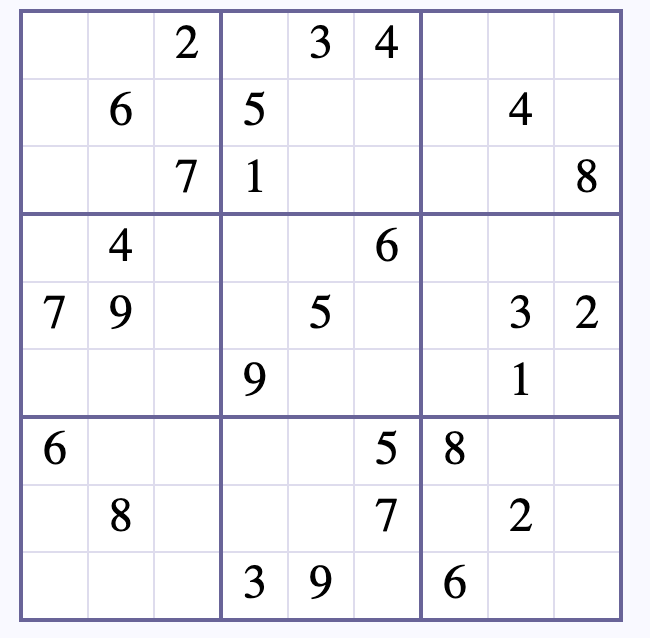

In [4]:
#Soduko puzzle
puzzle = Sudoku(np.array(
    [
        [0,0,0, 0,0,0, 0,0,0],
        [0,0,0, 0,0,0, 0,0,0],
        [0,0,0, 0,0,0, 0,0,0],

        [0,0,0, 0,0,0, 0,0,0],
        [0,0,0, 0,0,0, 0,0,0],
        [0,0,0, 0,0,0, 0,0,0],

        [0,0,0, 0,0,0, 0,0,0],
        [0,0,0, 0,0,0, 0,0,0],
        [0,0,0, 0,0,0, 0,0,0],
    ]))

puzzle = Sudoku(np.array(
[
    [0,0,2, 0,3,4, 0,0,0],
    [0,6,0, 5,0,0, 0,4,0],
    [0,0,7, 1,0,0, 0,0,8],
    
    [0,4,0, 0,0,6, 0,0,0],
    [7,9,0, 0,5,0, 0,3,2],
    [0,0,0, 9,0,0, 0,1,0],
    
    [6,0,0, 0,0,5, 8,0,0],
    [0,8,0, 0,0,7, 0,2,0],
    [0,0,0, 3,9,0, 6,0,0],
]))

In [6]:
puzzle.solve()
puzzle.brute_force()

----------------------------------------
|8   5   2   |7   3   4   |1   6   9   |
|            |            |            |
|            |            |            |
|1   6   9   |5   8   2   |3   4   7   |
|            |            |            |
|            |            |            |
|4   3   7   |1   6   9   |2   5   8   |
|            |            |            |
|            |            |            |
|------------+------------+------------|
|3   4   1   |2   7   6   |9   8   5   |
|            |            |            |
|            |            |            |
|7   9   6   |8   5   1   |4   3   2   |
|            |            |            |
|            |            |            |
|5   2   8   |9   4   3   |7   1   6   |
|            |            |            |
|            |            |            |
|------------+------------+------------|
|6   7   3   |4   2   5   |8   9   1   |
|            |            |            |
|            |            |            |
|9   8   4   |6 

In [154]:
puzzle.solve()

----------------------------------------
|8   5   2   |7   3   4   |1   6   9   |
|            |            |            |
|            |            |            |
|1   6   9   |5   8   2   |3   4   7   |
|            |            |            |
|            |            |            |
|4   3   7   |1   6   9   |2   5   8   |
|            |            |            |
|            |            |            |
|------------+------------+------------|
|3   4   1   |2   7   6   |9   8   5   |
|            |            |            |
|            |            |            |
|7   9   6   |8   5   1   |4   3   2   |
|            |            |            |
|            |            |            |
|5   2   8   |9   4   3   |7   1   6   |
|            |            |            |
|            |            |            |
|------------+------------+------------|
|6   7   3   |4   2   5   |8   9   1   |
|            |            |            |
|            |            |            |
|9   8   4   |6 

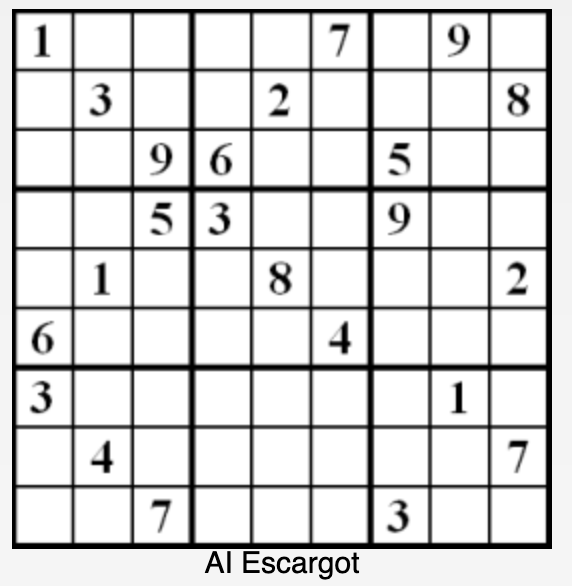

In [164]:
puzzle = Sudoku(np.array(
[
    [1,0,0, 0,0,7, 0,9,0],
    [0,3,0, 0,2,0, 0,0,8],
    [0,0,9, 6,0,0, 4,0,0],
    
    [0,0,5, 3,0,0, 9,0,0],
    [0,1,0, 0,8,0, 0,0,2],
    [6,0,0, 0,0,4, 0,0,0],
    
    [3,0,0, 0,0,0, 0,1,0],
    [0,4,0, 0,0,0, 0,0,7],
    [0,0,7, 0,0,0, 3,0,0],
]))

In [165]:
puzzle.solve()

----------------------------------------
|1   825 824 |845 345 7   |256 9   356 |
|    6   6   |            |            |
|            |            |            |
|457 3   46  |145 2   159 |156 567 8   |
|            |9           |7           |
|            |            |            |
|825 825 9   |6   135 813 |4   235 135 |
|7   7       |        5   |    7       |
|            |            |            |
|------------+------------+------------|
|824 827 5   |3   167 126 |9   846 146 |
|7           |            |    7       |
|            |            |            |
|947 1   34  |957 8   956 |567 345 2   |
|            |            |    67      |
|            |            |            |
|6   892 823 |125 159 4   |815 835 135 |
|    7       |79  7       |7   7       |
|            |            |            |
|------------+------------+------------|
|3   256 826 |245 456 256 |825 1   945 |
|    89      |789 79  89  |6       6   |
|            |            |            |
|892 4   1   |89

In [162]:
puzzle = Sudoku(np.array(
    [
        [0,7,4, 0,2,0, 5,1,0],
        [0,0,0, 0,0,0, 4,0,2],
        [0,6,0, 0,0,0, 3,0,7],

        [5,0,0, 0,7,0, 0,4,0],
        [0,0,9, 0,0,0, 2,7,5],
        [8,0,7, 5,0,0, 6,0,0],

        [0,1,0, 3,9,6, 7,0,0],
        [0,0,0, 0,0,0, 0,0,0],
        [7,0,0, 0,0,0, 0,0,9],
    ]))


In [163]:
puzzle.solve()

----------------------------------------
|3   7   4   |9   2   8   |5   1   6   |
|            |            |            |
|            |            |            |
|1   8   5   |7   6   3   |4   9   2   |
|            |            |            |
|            |            |            |
|9   6   2   |4   1   5   |3   8   7   |
|            |            |            |
|            |            |            |
|------------+------------+------------|
|5   3   1   |6   7   2   |9   4   8   |
|            |            |            |
|            |            |            |
|6   4   9   |8   3   1   |2   7   5   |
|            |            |            |
|            |            |            |
|8   2   7   |5   4   9   |6   3   1   |
|            |            |            |
|            |            |            |
|------------+------------+------------|
|2   1   8   |3   9   6   |7   5   4   |
|            |            |            |
|            |            |            |
|4   9   6   |1 

In [73]:
x=[[0 for x in range(9)] for y in range(9)]
print(np.array(x))

[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]


In [82]:
x=7
x - x%3

6

In [20]:
x != y

True

In [21]:
a=set([1,2,3])

In [23]:
list(a)[0]

1

In [24]:
a.pop()

1

In [25]:
a

{2, 3}

In [26]:
a.pop()

2

In [27]:
a

{3}

In [56]:
a=[[5,3], [4,4]]
True in map(lambda x: x[0]<x[1], a)

False

In [32]:
True in a

False

In [40]:
a.sort(key=lambda x: x[0])

In [41]:
a

[(4, 4), (5, 3)]

In [57]:
for x in a:
    x[0]=3
print(a)

[[3, 3], [3, 4]]


In [66]:
a=[1,2,1,3]
print(len(a))
print(len(set(a)))

4
3


In [68]:
[(x,y) for x in range(3) for y in range(3)]

[(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]

In [71]:
entries=[]
len(entries) == len(set(entries))

True

In [60]:
a,b,c=lst
print(b)

2


In [93]:
lst=[0,None,2]
[x for x in lst if x]

{0, 2, None}

In [63]:
b

2